# Notebook 2 — Feature Engineering
## Source : MODIS MOD13Q1 — NDVI 16 jours
## Zone : Mandoul, Moyen-Chari, Logone Occidental, Tchad | Période : 2010-2025
### Objectif : construire les features ML depuis la série temporelle NDVI

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv('ndvi-tchad-3regions-2010-2025-MOD13Q1-061-results.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(1038, 29)
['Category', 'ID', 'Latitude', 'Longitude', 'Date', 'MODIS_Tile', 'MOD13Q1_061_Line_Y_250m', 'MOD13Q1_061_Sample_X_250m', 'MOD13Q1_061__250m_16_days_EVI', 'MOD13Q1_061__250m_16_days_VI_Quality', 'MOD13Q1_061__250m_16_days_VI_Quality_bitmask', 'MOD13Q1_061__250m_16_days_VI_Quality_MODLAND', 'MOD13Q1_061__250m_16_days_VI_Quality_MODLAND_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_VI_Usefulness', 'MOD13Q1_061__250m_16_days_VI_Quality_VI_Usefulness_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_Aerosol_Quantity', 'MOD13Q1_061__250m_16_days_VI_Quality_Aerosol_Quantity_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_Adjacent_cloud_detected', 'MOD13Q1_061__250m_16_days_VI_Quality_Adjacent_cloud_detected_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_Atmosphere_BRDF_Correction', 'MOD13Q1_061__250m_16_days_VI_Quality_Atmosphere_BRDF_Correction_Description', 'MOD13Q1_061__250m_16_days_VI_Quality_Mixed_Clouds', 'MOD13Q1_061__250m_16_days_VI_Quality_Mixed_Clouds_De

## Nettoyer les données

In [ ]:
df_clean = df[[
    'Category',
    'Date',
    'MOD13Q1_061__250m_16_days_EVI',
    'MOD13Q1_061__250m_16_days_VI_Quality_MODLAND_Description'
]].copy()

df_clean.columns = [
    'region',
    'date',
    'evi',
    'qualite'
]

In [ ]:
print(df_clean['qualite'].unique())

['VI produced with good quality' 'VI produced, but check other QA'
 'Pixel produced, but most probably cloudy']


In [ ]:
df_clean = df_clean[df_clean['qualite'].isin(['VI produced with good quality', 'VI produced, but check other QA'])]

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values(by='date')

df_clean = df_clean.reset_index(drop=True)

print(df_clean)

                region       date     evi                        qualite
0    Logone-Occidental 2009-12-19  0.2302  VI produced with good quality
1              Mandoul 2009-12-19  0.2037  VI produced with good quality
2          Moyen-Chari 2009-12-19  0.2119  VI produced with good quality
3          Moyen-Chari 2010-01-01  0.2027  VI produced with good quality
4    Logone-Occidental 2010-01-01  0.1294  VI produced with good quality
..                 ...        ...     ...                            ...
958        Moyen-Chari 2024-12-02  0.3209  VI produced with good quality
959            Mandoul 2024-12-02  0.2798  VI produced with good quality
960  Logone-Occidental 2024-12-18  0.2128  VI produced with good quality
961            Mandoul 2024-12-18  0.2469  VI produced with good quality
962        Moyen-Chari 2024-12-18  0.2753  VI produced with good quality

[963 rows x 4 columns]


### Garder seulement les mois agricoles

In [ ]:
df_clean = df_clean[df_clean['date'].dt.month.isin([6, 7, 8, 9, 10, 11, 12])]
df_clean = df_clean.reset_index(drop=True)
print(df_clean)

                region       date     evi                          qualite
0    Logone-Occidental 2009-12-19  0.2302    VI produced with good quality
1              Mandoul 2009-12-19  0.2037    VI produced with good quality
2          Moyen-Chari 2009-12-19  0.2119    VI produced with good quality
3    Logone-Occidental 2010-06-10  0.2522  VI produced, but check other QA
4          Moyen-Chari 2010-06-10  0.3727  VI produced, but check other QA
..                 ...        ...     ...                              ...
512        Moyen-Chari 2024-12-02  0.3209    VI produced with good quality
513            Mandoul 2024-12-02  0.2798    VI produced with good quality
514  Logone-Occidental 2024-12-18  0.2128    VI produced with good quality
515            Mandoul 2024-12-18  0.2469    VI produced with good quality
516        Moyen-Chari 2024-12-18  0.2753    VI produced with good quality

[517 rows x 4 columns]


## Visualisation de la dataset

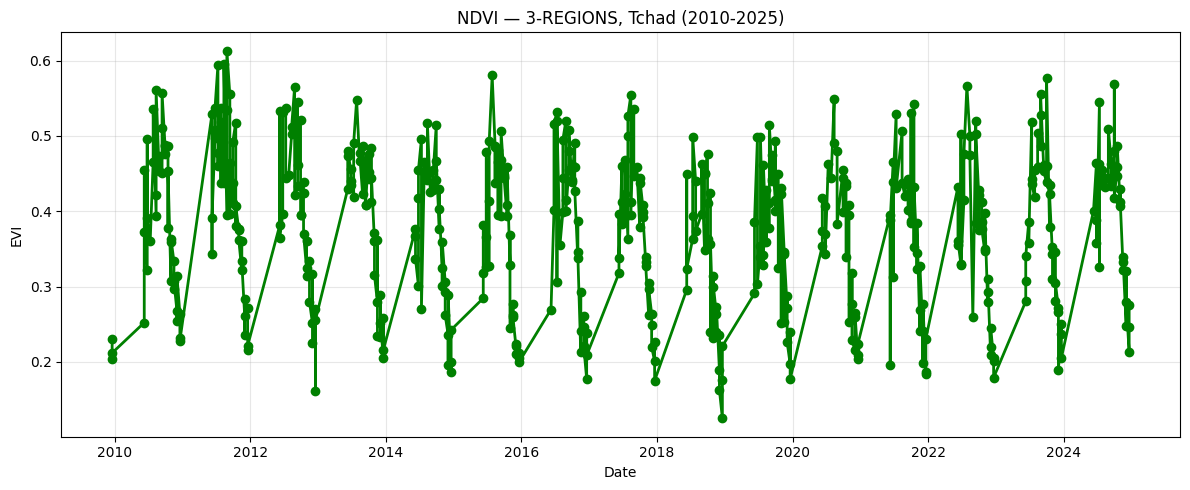

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df_clean["date"], df_clean["evi"], "o-", color="green", linewidth=2)
plt.title("NDVI — 3-REGIONS, Tchad (2010-2025)")
plt.xlabel("Date")
plt.ylabel("EVI")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ndvi_3regions.png", dpi=150)
plt.show()

## Calcul des premières features

In [ ]:
df_clean['annee'] = df_clean['date'].dt.year
df_clean['mois'] = df_clean['date'].dt.month
print(df_clean.head(10))

              region       date     evi                          qualite  \
0  Logone-Occidental 2009-12-19  0.2302    VI produced with good quality   
1            Mandoul 2009-12-19  0.2037    VI produced with good quality   
2        Moyen-Chari 2009-12-19  0.2119    VI produced with good quality   
3  Logone-Occidental 2010-06-10  0.2522  VI produced, but check other QA   
4        Moyen-Chari 2010-06-10  0.3727  VI produced, but check other QA   
5            Mandoul 2010-06-10  0.4542    VI produced with good quality   
6        Moyen-Chari 2010-06-26  0.3224  VI produced, but check other QA   
7            Mandoul 2010-06-26  0.4962    VI produced with good quality   
8  Logone-Occidental 2010-06-26  0.3908    VI produced with good quality   
9  Logone-Occidental 2010-07-12  0.3602  VI produced, but check other QA   

   annee  mois  
0   2009    12  
1   2009    12  
2   2009    12  
3   2010     6  
4   2010     6  
5   2010     6  
6   2010     6  
7   2010     6  
8   2010  

In [ ]:
features = df_clean.groupby(['annee', 'region'])['evi'].agg(
    evi_max      = 'max',
    evi_mean     = 'mean',
    evi_min      = 'min',
    evi_integral = 'sum'
).reset_index()

print(features)
print(f"\n{len(features)} lignes — attendu : 45")

    annee             region  evi_max  evi_mean  evi_min  evi_integral
0    2009  Logone-Occidental   0.2302  0.230200   0.2302        0.2302
1    2009            Mandoul   0.2037  0.203700   0.2037        0.2037
2    2009        Moyen-Chari   0.2119  0.211900   0.2119        0.2119
3    2010  Logone-Occidental   0.4873  0.355709   0.2322        3.9128
4    2010            Mandoul   0.5110  0.407825   0.2284        4.8939
5    2010        Moyen-Chari   0.5609  0.413442   0.2637        4.9613
6    2011  Logone-Occidental   0.5083  0.373958   0.2215        4.4875
7    2011            Mandoul   0.5945  0.462462   0.2715        6.0120
8    2011        Moyen-Chari   0.6132  0.429969   0.2157        5.5896
9    2012  Logone-Occidental   0.4335  0.332644   0.1612        2.9938
10   2012            Mandoul   0.5336  0.391264   0.2514        4.3039
11   2012        Moyen-Chari   0.5654  0.441315   0.2705        5.7371
12   2013  Logone-Occidental   0.4435  0.356430   0.2160        3.5643
13   2

### Ajout des features par phase

In [ ]:
vg  = df_clean[df_clean['mois'].isin([7, 8])].groupby(['annee', 'region'])['evi'].agg(
    evi_mean_vg = 'mean'
).reset_index()

fl  = df_clean[df_clean['mois'].isin([9])].groupby(['annee', 'region'])['evi'].agg(
    evi_max_fl = 'max'
).reset_index()

sn  = df_clean[df_clean['mois'].isin([10, 11])].groupby(['annee', 'region'])['evi'].agg(
    evi_mean_sn = 'mean'
).reset_index()

print(vg)
print(fl)
print(sn)

    annee             region  evi_mean_vg
0    2010  Logone-Occidental     0.377250
1    2010            Mandoul     0.446767
2    2010        Moyen-Chari     0.523200
3    2011  Logone-Occidental     0.430700
4    2011            Mandoul     0.525600
5    2011        Moyen-Chari     0.551175
6    2012            Mandoul     0.459100
7    2012        Moyen-Chari     0.513450
8    2013  Logone-Occidental     0.419500
9    2013            Mandoul     0.476250
10   2013        Moyen-Chari     0.484675
11   2014  Logone-Occidental     0.402600
12   2014            Mandoul     0.446800
13   2014        Moyen-Chari     0.506650
14   2015  Logone-Occidental     0.460000
15   2015            Mandoul     0.426500
16   2015        Moyen-Chari     0.476425
17   2016  Logone-Occidental     0.364950
18   2016            Mandoul     0.460067
19   2016        Moyen-Chari     0.515767
20   2017  Logone-Occidental     0.393633
21   2017            Mandoul     0.456675
22   2017        Moyen-Chari     0

### Fusion des features


In [ ]:
df_merge_1= pd.merge(features, vg, on=['annee', 'region'])

df_merge_2 = pd.merge(df_merge_1, fl, on=['annee', 'region'])

df_features = pd.merge(df_merge_2, sn, on=['annee', 'region'])

print(df_features)

    annee             region  evi_max  evi_mean  evi_min  evi_integral  \
0    2010  Logone-Occidental   0.4873  0.355709   0.2322        3.9128   
1    2010            Mandoul   0.5110  0.407825   0.2284        4.8939   
2    2010        Moyen-Chari   0.5609  0.413442   0.2637        4.9613   
3    2011  Logone-Occidental   0.5083  0.373958   0.2215        4.4875   
4    2011            Mandoul   0.5945  0.462462   0.2715        6.0120   
5    2011        Moyen-Chari   0.6132  0.429969   0.2157        5.5896   
6    2012            Mandoul   0.5336  0.391264   0.2514        4.3039   
7    2012        Moyen-Chari   0.5654  0.441315   0.2705        5.7371   
8    2013  Logone-Occidental   0.4435  0.356430   0.2160        3.5643   
9    2013            Mandoul   0.4861  0.411064   0.2588        4.5217   
10   2013        Moyen-Chari   0.5480  0.408585   0.2053        5.3116   
11   2014  Logone-Occidental   0.4657  0.344600   0.1864        4.4798   
12   2014            Mandoul   0.5147 

In [ ]:
# Compter le nombre de régions par année
regions_par_annee = df_features.groupby('annee')['region'].count()
print(regions_par_annee)
print(f"\nAnnées incomplètes : {list(regions_par_annee[regions_par_annee < 3].index)}")

annee
2010    3
2011    3
2012    2
2013    3
2014    3
2015    3
2016    3
2017    3
2018    3
2019    3
2020    2
2021    3
2022    2
2023    3
2024    3
Name: region, dtype: int64

Années incomplètes : [2012, 2020, 2022]


In [ ]:
# Années avec exactement 3 régions
annees_completes = regions_par_annee[regions_par_annee == 3].index

# Filtrer
df_features = df_features[df_features['annee'].isin(annees_completes)].reset_index(drop=True)

print(f"Nombre de lignes : {len(df_features)}")
print(df_features['annee'].unique())

Nombre de lignes : 36
[2010 2011 2013 2014 2015 2016 2017 2018 2019 2021 2023 2024]


# Chargement et exploration des données FAO
## Valeur rendement

In [ ]:
df_fao = pd.read_csv('FAOSTAT_data_en_3-23-2026.csv')
print(df_fao.shape)
print(df_fao.columns.tolist())
print(df_fao)

(30, 15)
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']
   Domain Code                        Domain  Area Code (M49)  Area  \
0          QCL  Crops and livestock products              148  Chad   
1          QCL  Crops and livestock products              148  Chad   
2          QCL  Crops and livestock products              148  Chad   
3          QCL  Crops and livestock products              148  Chad   
4          QCL  Crops and livestock products              148  Chad   
5          QCL  Crops and livestock products              148  Chad   
6          QCL  Crops and livestock products              148  Chad   
7          QCL  Crops and livestock products              148  Chad   
8          QCL  Crops and livestock products              148  Chad   
9          QCL  Crops and livestock products              148  Chad   
10         QCL  Crops and liv

## Préparer la variable cible

In [ ]:
df_fao = df_fao[[
    'Year',
    'Value'
]].copy()

In [ ]:
df_fao = df_fao.groupby('Year').agg(
    Value_mean = ('Value', 'mean')
).reset_index()

df_fao['Value_mean'] = df_fao['Value_mean'] * 0.001

df_fao.columns = [
    'annee',
    'rendement_t_ha'
]

print(df_fao)

    annee  rendement_t_ha
0    2010         0.64555
1    2011         0.49330
2    2012         0.82420
3    2013         0.62485
4    2014         0.73560
5    2015         0.65835
6    2016         0.71225
7    2017         0.69560
8    2018         0.74320
9    2019         0.73825
10   2020         0.71570
11   2021         0.67445
12   2022         0.71315
13   2023         0.67580
14   2024         0.62580


In [ ]:
# Filtrer
df_fao = df_fao[df_fao['annee'].isin(annees_completes)].reset_index(drop=True)

print(f"Nombre de lignes : {len(df_fao)}")
print(df_fao['annee'].unique())
print(df_fao)

Nombre de lignes : 12
[2010 2011 2013 2014 2015 2016 2017 2018 2019 2021 2023 2024]
    annee  rendement_t_ha
0    2010         0.64555
1    2011         0.49330
2    2013         0.62485
3    2014         0.73560
4    2015         0.65835
5    2016         0.71225
6    2017         0.69560
7    2018         0.74320
8    2019         0.73825
9    2021         0.67445
10   2023         0.67580
11   2024         0.62580


In [ ]:
df_fao.to_csv('dataset_fao.csv', index=False)
print(f"✅ {len(df_fao)} lignes sauvegardées")

✅ 12 lignes sauvegardées


 ## Extraction des valeurs pluivieuses

In [ ]:
!pip install rasterio -q
import rasterio
import requests
import xarray as xr

url = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_monthly/netcdf/chirps-v2.0.monthly.nc"

ds = xr.open_dataset(url, engine='h5netcdf')
print(ds)

<xarray.Dataset> Size: 31GB
Dimensions:    (time: 542, latitude: 2000, longitude: 7200)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2026-02-01
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    precip     (time, latitude, longitude) float32 31GB ...
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2026-03-16
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given month.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/ch

In [ ]:
regions = {
    'Mandoul'           : (9.010660,  17.385999),
    'Moyen-Chari'       : (9.536610,  18.703175),
    'Logone-Occidental' : (8.719645,  15.766285)
}

resultats = []

for region, (lat, lon) in regions.items():
    print(f"⏳ Extraction {region}...")

    # Extraire le point le plus proche
    point = ds.sel(
        latitude=lat,
        longitude=lon,
        method='nearest'
    )['precip']

    # Convertir en DataFrame
    df_temp = point.to_dataframe().reset_index()
    df_temp['region'] = region
    df_temp['annee']  = df_temp['time'].dt.year
    df_temp['mois']   = df_temp['time'].dt.month

    # Filtrer 2010-2024 et mois agricoles
    df_temp = df_temp[
        (df_temp['annee'].between(2010, 2024)) &
        (df_temp['mois'].isin([6,7,8,9,10,11]))
    ]

    # Cumul saisonnier par année
    df_annuel = df_temp.groupby(['annee', 'region'])['precip'].sum().reset_index()
    df_annuel.columns = ['annee', 'region', 'pluie_saison_mm']

    resultats.append(df_annuel)
    print(f"✅ {region} terminé")

df_pluie = pd.concat(resultats).reset_index(drop=True)
print(df_pluie)

⏳ Extraction Mandoul...
✅ Mandoul terminé
⏳ Extraction Moyen-Chari...
✅ Moyen-Chari terminé
⏳ Extraction Logone-Occidental...
✅ Logone-Occidental terminé
    annee             region  pluie_saison_mm
0    2010            Mandoul      1031.795654
1    2011            Mandoul      1037.226685
2    2012            Mandoul      1147.767822
3    2013            Mandoul       935.355164
4    2014            Mandoul       907.835266
5    2015            Mandoul       986.665588
6    2016            Mandoul       836.571533
7    2017            Mandoul       939.453491
8    2018            Mandoul       763.794434
9    2019            Mandoul      1078.059082
10   2020            Mandoul      1032.080322
11   2021            Mandoul      1150.282715
12   2022            Mandoul      1071.328247
13   2023            Mandoul       795.259583
14   2024            Mandoul      1282.122070
15   2010        Moyen-Chari       922.228516
16   2011        Moyen-Chari       889.119507
17   2012        M

In [ ]:
# Filtrer
df_pluie = df_pluie[df_pluie['annee'].isin(annees_completes)].reset_index(drop=True)

print(f"Nombre de lignes : {len(df_pluie)}")
print(df_pluie['annee'].unique())

Nombre de lignes : 36
[2010 2011 2013 2014 2015 2016 2017 2018 2019 2021 2023 2024]


In [ ]:
df_features_pluie = pd.merge(df_features, df_pluie, on=['annee', 'region'])
print(df_features_pluie)

    annee             region  evi_max  evi_mean  evi_min  evi_integral  \
0    2010  Logone-Occidental   0.4873  0.355709   0.2322        3.9128   
1    2010            Mandoul   0.5110  0.407825   0.2284        4.8939   
2    2010        Moyen-Chari   0.5609  0.413442   0.2637        4.9613   
3    2011  Logone-Occidental   0.5083  0.373958   0.2215        4.4875   
4    2011            Mandoul   0.5945  0.462462   0.2715        6.0120   
5    2011        Moyen-Chari   0.6132  0.429969   0.2157        5.5896   
6    2013  Logone-Occidental   0.4435  0.356430   0.2160        3.5643   
7    2013            Mandoul   0.4861  0.411064   0.2588        4.5217   
8    2013        Moyen-Chari   0.5480  0.408585   0.2053        5.3116   
9    2014  Logone-Occidental   0.4657  0.344600   0.1864        4.4798   
10   2014            Mandoul   0.5147  0.370309   0.1994        4.0734   
11   2014        Moyen-Chari   0.5174  0.396927   0.2426        4.3662   
12   2015  Logone-Occidental   0.5062 

## Dataset final

In [ ]:
df_final = pd.merge(df_features_pluie, df_fao, on='annee')
print(df_final.shape)
print(df_final.columns)

(36, 11)
Index(['annee', 'region', 'evi_max', 'evi_mean', 'evi_min', 'evi_integral',
       'evi_mean_vg', 'evi_max_fl', 'evi_mean_sn', 'pluie_saison_mm',
       'rendement_t_ha'],
      dtype='object')


In [ ]:
df_final.to_csv('dataset_ml_3régions_V2.csv', index=False)
print(f"✅ {len(df_final)} lignes sauvegardées")

✅ 36 lignes sauvegardées
